In [1]:
# Importaciones principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
from datetime import datetime
import warnings

# Configuracion de visualizacion
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo de graficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Librerias cargadas exitosamente")
print(f"Fecha de analisis: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Librerias cargadas exitosamente
Fecha de analisis: 2026-02-15 16:08:21


In [2]:
# Conectar a la base de datos
load_dotenv()

DB_NAME = os.getenv("DB_NAME")
DB_HOST = os.getenv("DB_HOST")
DB_PASS = os.getenv("DB_PASS")
DB_PORT = os.getenv("DB_PORT", "5433")
DB_USER = os.getenv("DB_USER")

engine = create_engine(
    f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    connect_args={"connect_timeout": 10}
)

# Verificar conexion
with engine.connect() as conn:
    result = conn.execute(text("SELECT 1"))
    print("Conexion exitosa a la base de datos")

# Cargar datos de RB
query = "SELECT * FROM rb_data ORDER BY season DESC, week DESC, p_name"
with engine.connect() as conn:
    df_rb = pd.read_sql(text(query), conn)

print(f"Total de registros: {len(df_rb):,}")
print(f"Columnas: {df_rb.columns.tolist()}")

Conexion exitosa a la base de datos
Total de registros: 1,565
Columnas: ['season', 'week', 'p_name', 'team', 'rush_attempts', 'rush_yards', 'avg_rush_yards', 'rush_touchdowns', 'receiving_receptions', 'receiving_rectd', 'receiving_targets', 'receiving_recyds', 'player_gsis_id', 'g_location', 'team_against', 'total_yards', 'passing_yards', 'rushing_yards', 'turnovers', 'sacks', 'points_allowed']


In [3]:
# Ver estructura de datos y estadisticas basicas
print("Primeras filas:")
print(df_rb.head(10))
print("\n" + "="*80)
print("\nInfo del DataFrame:")
print(df_rb.info())
print("\n" + "="*80)
print("\nEstadisticas descriptivas:")
print(df_rb.describe())

Primeras filas:
   season  week               p_name team  rush_attempts  rush_yards  \
0    2025    17          Aaron Jones  MIN             18          53   
1    2025    17        Ashton Jeanty   LV             16          60   
2    2025    17       Bijan Robinson  ATL             22         195   
3    2025    17          Breece Hall  NYJ             14         111   
4    2025    17          Chase Brown  CIN             22         101   
5    2025    17  Christian McCaffrey   SF             23         140   
6    2025    17     David Montgomery  DET             10          25   
7    2025    17        Derrick Henry  BAL             36         216   
8    2025    17        De'Von Achane  MIA             18          83   
9    2025    17        Dylan Sampson  CLE             11          27   

   avg_rush_yards  rush_touchdowns  receiving_receptions  receiving_rectd  \
0            2.94                1                  3.00             0.00   
1            3.75                0   

In [4]:
# Ver la distribucion de temporadas y semanas disponibles
print("Distribucion por temporada:")
print(df_rb["season"].value_counts().sort_index())
print("\nDistribucion por semana:")
print(df_rb["week"].value_counts().sort_index())
print("\n" + "="*80)
print("\nValores nulos por columna:")
nulos = df_rb.isnull().sum()
print(nulos[nulos > 0])

Distribucion por temporada:
2023    534
2024    531
2025    500
Name: season, dtype: int64

Distribucion por semana:
1     98
2     96
3     93
4     93
5     74
6     85
7     88
8     88
9     87
10    83
11    88
12    66
13    92
14    93
15    95
16    88
17    97
18    61
Name: week, dtype: int64


Valores nulos por columna:
receiving_receptions    783
receiving_rectd         783
receiving_targets       783
receiving_recyds        783
sacks                   345
dtype: int64


In [5]:
# Entender los nulos en receiving - son por temporada?
print("Nulos en receiving_receptions por temporada:")
print(df_rb.groupby("season")["receiving_receptions"].apply(lambda x: x.isnull().sum()))
print(f"\nTotal registros por temporada:")
print(df_rb["season"].value_counts().sort_index())
print(f"\n" + "="*80)
print(f"\nConclusión:")
print(f"Registros con datos de receiving: {df_rb['receiving_receptions'].notna().sum()}")
print(f"Registros 2025: {len(df_rb[df_rb['season'] == 2025])}")
print(f"\nRegistros SIN datos de receiving por temporada:")
for season in [2023, 2024, 2025]:
    sin_datos = df_rb[df_rb['season'] == season]['receiving_receptions'].isnull().sum()
    total = len(df_rb[df_rb['season'] == season])
    print(f"  {season}: {sin_datos}/{total} ({sin_datos/total*100:.1f}%)")

Nulos en receiving_receptions por temporada:
season
2023    534
2024     52
2025    197
Name: receiving_receptions, dtype: int64

Total registros por temporada:
2023    534
2024    531
2025    500
Name: season, dtype: int64


Conclusión:
Registros con datos de receiving: 782
Registros 2025: 500

Registros SIN datos de receiving por temporada:
  2023: 534/534 (100.0%)
  2024: 52/531 (9.8%)
  2025: 197/500 (39.4%)


In [6]:
# Ver cuantos RBs unicos hay y su distribucion de juegos
rb_counts = df_rb.groupby("player_gsis_id")["p_name"].agg(["first", "count"])
rb_counts.columns = ["nombre", "juegos"]
rb_counts = rb_counts.sort_values("juegos", ascending=False)

print(f"Total RBs unicos: {len(rb_counts)}")
print(f"\nTop 20 RBs por cantidad de juegos:")
print(rb_counts.head(20))
print(f"\n" + "="*80)
print(f"\nDistribucion de juegos jugados:")
print(rb_counts["juegos"].describe())
print(f"\nRBs con solo 1 juego: {len(rb_counts[rb_counts['juegos'] == 1])}")
print(f"RBs con 10+ juegos: {len(rb_counts[rb_counts['juegos'] >= 10])}")
print(f"RBs con 20+ juegos: {len(rb_counts[rb_counts['juegos'] >= 20])}")
print(f"RBs con 30+ juegos: {len(rb_counts[rb_counts['juegos'] >= 30])}")

Total RBs unicos: 129

Top 20 RBs por cantidad de juegos:
                             nombre  juegos
player_gsis_id                             
00-0032764            Derrick Henry      47
00-0038542           Bijan Robinson      45
00-0037840           Kyren Williams      44
00-0037248               James Cook      43
00-0034844           Saquon Barkley      43
00-0036275            D'Andre Swift      41
00-0035261             Tony Pollard      41
00-0038120              Breece Hall      39
00-0036973           Travis Etienne      39
00-0035700              Josh Jacobs      39
00-0039139             Jahmyr Gibbs      38
00-0036223          Jonathan Taylor      36
00-0036997         Javonte Williams      34
00-0033280      Christian McCaffrey      33
00-0036555            Chuba Hubbard      33
00-0037256            Rachaad White      32
00-0038134       Kenneth Walker III      32
00-0036893             Najee Harris      30
00-0039040            De'Von Achane      29
00-0035685        

In [7]:
# Analisis de correlaciones
# Seleccionar solo columnas numericas relevantes para RBs
rb_stats = df_rb[[
    'rush_attempts', 'rush_yards', 'avg_rush_yards', 'rush_touchdowns',
    'receiving_receptions', 'receiving_rectd', 'receiving_targets', 'receiving_recyds',
    'total_yards', 'passing_yards', 'rushing_yards', 'turnovers', 'points_allowed'
]].copy()

print("Matriz de correlacion (stats de RB vs stats del equipo):")
print("="*80)
correlaciones = rb_stats.corr()
print(correlaciones[['rush_yards', 'rush_touchdowns', 'receiving_recyds']].sort_values('rush_yards', ascending=False))

print("\n" + "="*80)
print("\nCorrelaciones con rush_yards (principal metrica):")
rush_corr = correlaciones['rush_yards'].sort_values(ascending=False)
print(rush_corr)

Matriz de correlacion (stats de RB vs stats del equipo):
                      rush_yards  rush_touchdowns  receiving_recyds
rush_yards                  1.00             0.36              0.02
avg_rush_yards              0.76             0.25              0.01
rush_attempts               0.67             0.26              0.02
rushing_yards               0.65             0.26             -0.06
rush_touchdowns             0.36             1.00              0.04
total_yards                 0.33             0.22              0.20
receiving_rectd             0.10            -0.01              0.26
receiving_recyds            0.02             0.04              1.00
receiving_receptions       -0.02            -0.03              0.69
receiving_targets          -0.02            -0.06              0.63
points_allowed             -0.04             0.01              0.08
passing_yards              -0.07             0.08              0.28
turnovers                  -0.08            -0.14          

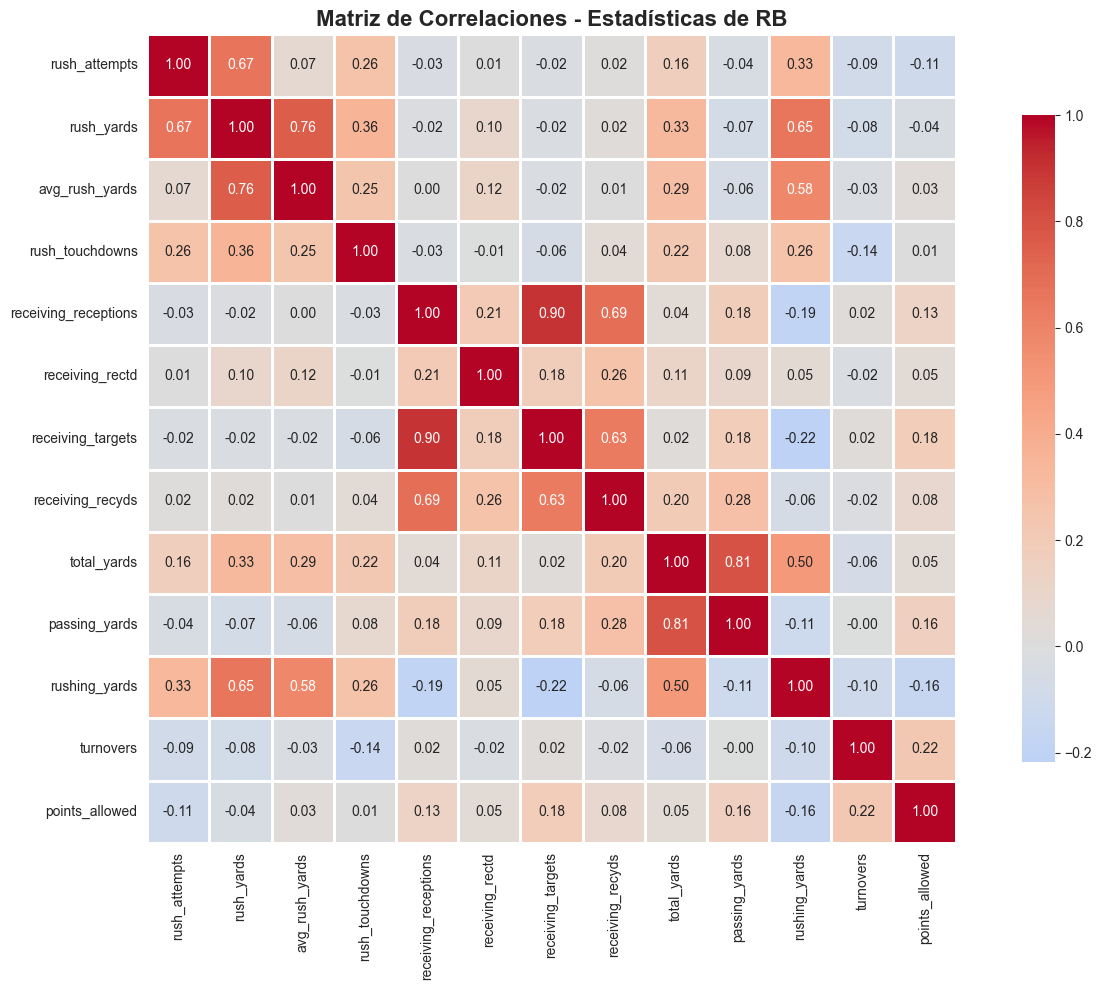

Mapa de calor generado


In [8]:
# Grafico de correlaciones
plt.figure(figsize=(14, 10))
sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlaciones - Estadísticas de RB', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Mapa de calor generado")

In [9]:
# FEATURE ENGINEERING
# Crear features historicas con ventanas moviles

print("Iniciando Feature Engineering...")
print("="*80)

# Ordenar por jugador y fecha (season, week)
df_rb = df_rb.sort_values(['player_gsis_id', 'season', 'week']).reset_index(drop=True)

# Variables para las que crearemos features historicas
variables_rushing = ['rush_yards', 'rush_attempts', 'rush_touchdowns', 'avg_rush_yards']
variables_receiving = ['receiving_receptions', 'receiving_recyds', 'receiving_rectd', 'receiving_targets']
variables_equipo = ['total_yards', 'passing_yards', 'rushing_yards']

# Combinar todas las variables
todas_variables = variables_rushing + variables_receiving + variables_equipo

# Ventanas a usar (como en QB analysis)
ventanas = [3, 5]

print(f"Variables a procesar: {len(todas_variables)}")
print(f"Ventanas: {ventanas}")
print(f"\nCreando features...")

# Crear features historicas
for var in todas_variables:
    for ventana in ventanas:
        # Promedio movil (excluyendo el juego actual con shift(1))
        df_rb[f'{var}_avg_{ventana}'] = (
            df_rb.groupby('player_gsis_id')[var]
            .transform(lambda x: x.shift(1).rolling(ventana, min_periods=1).mean())
        )
        
        # Desviacion estandar (para medir consistencia)
        df_rb[f'{var}_std_{ventana}'] = (
            df_rb.groupby('player_gsis_id')[var]
            .transform(lambda x: x.shift(1).rolling(ventana, min_periods=1).std())
        )

print(f"✓ Features de ventanas moviles creadas")

# Crear tendencias (diferencia entre ventanas de 3 y 5 juegos)
for var in todas_variables:
    df_rb[f'{var}_trend'] = df_rb[f'{var}_avg_3'] - df_rb[f'{var}_avg_5']

print(f"✓ Features de tendencias creadas")

# Features de experiencia
df_rb['juegos_acumulados'] = df_rb.groupby('player_gsis_id').cumcount()

# Promedios de carrera (expanding mean)
for var in todas_variables:
    df_rb[f'{var}_carrera_avg'] = (
        df_rb.groupby('player_gsis_id')[var]
        .transform(lambda x: x.shift(1).expanding().mean())
    )

print(f"✓ Features de experiencia creadas")

print(f"\n" + "="*80)
print(f"Total de columnas ahora: {len(df_rb.columns)}")
print(f"Features creadas: {len(df_rb.columns) - 21} nuevas features")

# Ver algunas de las nuevas features
print(f"\nEjemplo de nuevas features (primeras 10):")
nuevas_cols = [col for col in df_rb.columns if '_avg_' in col or '_std_' in col or '_trend' in col or '_carrera_' in col]
print(nuevas_cols[:10])

Iniciando Feature Engineering...
Variables a procesar: 11
Ventanas: [3, 5]

Creando features...
✓ Features de ventanas moviles creadas
✓ Features de tendencias creadas
✓ Features de experiencia creadas

Total de columnas ahora: 88
Features creadas: 67 nuevas features

Ejemplo de nuevas features (primeras 10):
['rush_yards_avg_3', 'rush_yards_std_3', 'rush_yards_avg_5', 'rush_yards_std_5', 'rush_attempts_avg_3', 'rush_attempts_std_3', 'rush_attempts_avg_5', 'rush_attempts_std_5', 'rush_touchdowns_avg_3', 'rush_touchdowns_std_3']


In [ ]:
# Preparacion de datos para modelado
print("PREPARACION DE DATOS")
print("="*80)

# Ver nulos por columna
nulos = df_rb.isnull().sum().sort_values(ascending=False)
print(f"Columnas con nulos:")
print(nulos[nulos > 0].head(20))

print(f"\n" + "="*80)
# Contar filas con muchos nulos
umbral_nulos = 5
filas_con_muchos_nulos = (df_rb.isnull().sum(axis=1) > umbral_nulos).sum()
print(f"\nFilas con más de {umbral_nulos} nulos: {filas_con_muchos_nulos} de {len(df_rb)} ({filas_con_muchos_nulos/len(df_rb)*100:.1f}%)")

# Ver distribucion de nulos por fila
print(f"\nDistribución de nulos por fila:")
nulos_por_fila = df_rb.isnull().sum(axis=1)
print(nulos_por_fila.describe())

In [10]:
# PREPARACION DE DATOS PARA MODELADO
print("PREPARACIÓN DE DATOS - MODELO RUSHING")
print("="*80)

# Definir targets (lo que queremos predecir)
targets = ['rush_yards', 'rush_attempts', 'rush_touchdowns', 'avg_rush_yards']
print(f"Targets a predecir: {targets}")

# Columnas a excluir (leakage - info del juego actual o receiving que no usaremos)
excluir_cols = [
    # Targets
    'rush_yards', 'rush_attempts', 'rush_touchdowns', 'avg_rush_yards',
    # Receiving (no las usaremos en este modelo)
    'receiving_receptions', 'receiving_rectd', 'receiving_targets', 'receiving_recyds',
    # Identificadores
    'player_gsis_id', 'p_name', 'team', 'team_against', 'season', 'week', 'g_location',
    # Stats de equipo del mismo juego (leakage potencial)
    'total_yards', 'passing_yards', 'rushing_yards', 'turnovers', 'sacks', 'points_allowed'
]

# Features que usaremos (todas excepto las excluidas)
feature_cols = [col for col in df_rb.columns if col not in excluir_cols]

print(f"\nTotal features disponibles: {len(feature_cols)}")
print(f"Columnas excluidas: {len(excluir_cols)}")

# Ver cuántos nulos hay en las features
print(f"\n" + "="*80)
print("Análisis de nulos en las features:")
nulos_features = df_rb[feature_cols].isnull().sum().sum()
print(f"Total nulos en features: {nulos_features:,}")

# Ver distribución de nulos por fila
nulos_por_fila = df_rb[feature_cols].isnull().sum(axis=1)
print(f"\nNulos por fila - estadísticas:")
print(nulos_por_fila.describe())

# Filtrar filas con demasiados nulos (umbral: >5 nulos en features)
umbral_nulos = 5
filas_muchos_nulos = nulos_por_fila > umbral_nulos
print(f"\nFilas con más de {umbral_nulos} nulos: {filas_muchos_nulos.sum()} ({filas_muchos_nulos.sum()/len(df_rb)*100:.1f}%)")

# Crear dataset limpio
df_clean = df_rb[~filas_muchos_nulos].copy()
print(f"\nDataset después de filtrar: {len(df_clean):,} filas (removidas {len(df_rb) - len(df_clean)})")

print(f"\n" + "="*80)
print("Primeras 10 features:")
print(feature_cols[:10])

PREPARACIÓN DE DATOS - MODELO RUSHING
Targets a predecir: ['rush_yards', 'rush_attempts', 'rush_touchdowns', 'avg_rush_yards']

Total features disponibles: 67
Columnas excluidas: 21

Análisis de nulos en las features:
Total nulos en features: 25,404

Nulos por fila - estadísticas:
count   1565.00
mean      16.23
std       19.11
min        0.00
25%        0.00
50%        8.00
75%       24.00
max       66.00
dtype: float64

Filas con más de 5 nulos: 872 (55.7%)

Dataset después de filtrar: 693 filas (removidas 872)

Primeras 10 features:
['rush_yards_avg_3', 'rush_yards_std_3', 'rush_yards_avg_5', 'rush_yards_std_5', 'rush_attempts_avg_3', 'rush_attempts_std_3', 'rush_attempts_avg_5', 'rush_attempts_std_5', 'rush_touchdowns_avg_3', 'rush_touchdowns_std_3']


In [11]:
# Rellenar nulos restantes con la mediana de cada columna
print("Rellenando nulos restantes con la mediana...")
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df_clean[feature_cols] = imputer.fit_transform(df_clean[feature_cols])

print(f"✓ Nulos rellenados")
print(f"Verificación - nulos restantes en features: {df_clean[feature_cols].isnull().sum().sum()}")

# Dividir en train/test (2023-2024 train, 2025 test)
print(f"\n" + "="*80)
print("División Train/Test:")

train_data = df_clean[df_clean['season'].isin([2023, 2024])].copy()
test_data = df_clean[df_clean['season'] == 2025].copy()

print(f"Train (2023-2024): {len(train_data)} filas")
print(f"Test (2025): {len(test_data)} filas")

# Distribución por temporada
print(f"\nDistribución por temporada:")
print(df_clean['season'].value_counts().sort_index())

# Verificar que tenemos datos para todos los targets
print(f"\n" + "="*80)
print("Verificación de targets:")
for target in targets:
    print(f"{target}:")
    print(f"  Train - Min: {train_data[target].min():.2f}, Max: {train_data[target].max():.2f}, Media: {train_data[target].mean():.2f}")
    print(f"  Test  - Min: {test_data[target].min():.2f}, Max: {test_data[target].max():.2f}, Media: {test_data[target].mean():.2f}")

Rellenando nulos restantes con la mediana...
✓ Nulos rellenados
Verificación - nulos restantes en features: 0

División Train/Test:
Train (2023-2024): 369 filas
Test (2025): 324 filas

Distribución por temporada:
2024    369
2025    324
Name: season, dtype: int64

Verificación de targets:
rush_yards:
  Train - Min: 4.00, Max: 255.00, Media: 75.44
  Test  - Min: 3.00, Max: 244.00, Media: 70.12
rush_attempts:
  Train - Min: 10.00, Max: 34.00, Media: 16.70
  Test  - Min: 10.00, Max: 36.00, Media: 15.57
rush_touchdowns:
  Train - Min: 0.00, Max: 3.00, Media: 0.60
  Test  - Min: 0.00, Max: 4.00, Media: 0.55
avg_rush_yards:
  Train - Min: 0.40, Max: 11.55, Media: 4.49
  Test  - Min: 0.30, Max: 14.60, Media: 4.46


In [12]:
# Importar librerías de ML
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("COMPARACIÓN DE MODELOS")
print("="*80)

# Preparar datos
X_train = train_data[feature_cols]
X_test = test_data[feature_cols]

# Escalar features con RobustScaler (maneja outliers mejor)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Datos escalados con RobustScaler")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")

# Definir modelos a comparar
modelos = {
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.1, random_state=42, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=5000),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
}

print(f"\nModelos a comparar: {list(modelos.keys())}")
print(f"Entrenando para cada target...")

# Almacenar resultados
resultados = {target: {} for target in targets}

print("\nEsto puede tomar unos minutos...")

COMPARACIÓN DE MODELOS
✓ Datos escalados con RobustScaler
X_train shape: (369, 67)
X_test shape: (324, 67)

Modelos a comparar: ['Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'GradientBoosting', 'XGBoost']
Entrenando para cada target...

Esto puede tomar unos minutos...


In [13]:
# Entrenar y evaluar modelos para cada target
for target in targets:
    print(f"\n{'='*80}")
    print(f"TARGET: {target.upper()}")
    print('='*80)
    
    y_train = train_data[target]
    y_test = test_data[target]
    
    for nombre, modelo in modelos.items():
        # Entrenar
        modelo.fit(X_train_scaled, y_train)
        
        # Predecir
        y_train_pred = modelo.predict(X_train_scaled)
        y_test_pred = modelo.predict(X_test_scaled)
        
        # Calcular métricas
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        
        # Guardar resultados
        resultados[target][nombre] = {
            'train_r2': train_r2,
            'test_r2': test_r2,
            'mae': test_mae,
            'rmse': test_rmse
        }
        
        print(f"{nombre:20} | Train R²: {train_r2:6.3f} | Test R²: {test_r2:6.3f} | MAE: {test_mae:7.2f} | RMSE: {test_rmse:7.2f}")

print(f"\n{'='*80}")
print("✓ Todos los modelos entrenados")


TARGET: RUSH_YARDS
Ridge                | Train R²:  0.329 | Test R²: -0.311 | MAE:   31.66 | RMSE:   42.01
Lasso                | Train R²:  0.310 | Test R²: -0.235 | MAE:   30.74 | RMSE:   40.77
ElasticNet           | Train R²:  0.290 | Test R²: -0.180 | MAE:   30.26 | RMSE:   39.85
RandomForest         | Train R²:  0.824 | Test R²: -0.066 | MAE:   29.31 | RMSE:   37.87
GradientBoosting     | Train R²:  0.995 | Test R²: -0.288 | MAE:   32.02 | RMSE:   41.64
XGBoost              | Train R²:  0.993 | Test R²: -0.177 | MAE:   30.27 | RMSE:   39.81

TARGET: RUSH_ATTEMPTS
Ridge                | Train R²:  0.326 | Test R²: -0.369 | MAE:    4.31 | RMSE:    5.32
Lasso                | Train R²:  0.272 | Test R²: -0.103 | MAE:    3.86 | RMSE:    4.78
ElasticNet           | Train R²:  0.288 | Test R²: -0.146 | MAE:    3.94 | RMSE:    4.87
RandomForest         | Train R²:  0.847 | Test R²:  0.009 | MAE:    3.63 | RMSE:    4.53
GradientBoosting     | Train R²:  0.993 | Test R²: -0.228 | MAE:   

In [14]:
# Analizar qué puede estar causando el problema
print("DIAGNÓSTICO DEL PROBLEMA")
print("="*80)

# 1. Verificar distribución de targets entre train y test
print("1. Comparación de distribuciones Train vs Test:")
print("\n" + "-"*80)
for target in targets:
    print(f"\n{target}:")
    print(f"  Train: Media={train_data[target].mean():.2f}, Std={train_data[target].std():.2f}")
    print(f"  Test:  Media={test_data[target].mean():.2f}, Std={test_data[target].std():.2f}")
    print(f"  Diferencia: {abs(train_data[target].mean() - test_data[target].mean()):.2f}")

# 2. Ver importancia de features con Lasso (el más conservador)
print("\n" + "="*80)
print("2. Feature Importance con Lasso (rush_yards):")
print("-"*80)

# Entrenar Lasso para rush_yards
lasso_model = Lasso(alpha=0.1, random_state=42, max_iter=5000)
lasso_model.fit(X_train_scaled, train_data['rush_yards'])

# Obtener coeficientes
coefs = pd.DataFrame({
    'feature': feature_cols,
    'coef': np.abs(lasso_model.coef_)
}).sort_values('coef', ascending=False)

print(f"\nTop 15 features más importantes:")
print(coefs.head(15))

print(f"\nFeatures con coeficiente = 0 (eliminadas por Lasso): {(coefs['coef'] == 0).sum()} de {len(coefs)}")

# 3. Verificar ratio muestras/features
print("\n" + "="*80)
print("3. Ratio muestras/features:")
print(f"Muestras train: {len(train_data)}")
print(f"Features: {len(feature_cols)}")
print(f"Ratio: {len(train_data)/len(feature_cols):.2f}:1")
print(f"\nRecomendado: >10:1, Tenemos: {len(train_data)/len(feature_cols):.2f}:1 ⚠️")

DIAGNÓSTICO DEL PROBLEMA
1. Comparación de distribuciones Train vs Test:

--------------------------------------------------------------------------------

rush_yards:
  Train: Media=75.44, Std=36.34
  Test:  Media=70.12, Std=36.74
  Diferencia: 5.32

rush_attempts:
  Train: Media=16.70, Std=5.02
  Test:  Media=15.57, Std=4.56
  Diferencia: 1.13

rush_touchdowns:
  Train: Media=0.60, Std=0.72
  Test:  Media=0.55, Std=0.73
  Diferencia: 0.05

avg_rush_yards:
  Train: Media=4.49, Std=1.67
  Test:  Media=4.46, Std=1.89
  Diferencia: 0.02

2. Feature Importance con Lasso (rush_yards):
--------------------------------------------------------------------------------

Top 15 features más importantes:
                        feature  coef
27        receiving_rectd_std_5 17.14
26        receiving_rectd_avg_5 14.40
17   receiving_receptions_std_3 11.31
62  receiving_rectd_carrera_avg 10.84
1              rush_yards_std_3 10.01
2              rush_yards_avg_5  9.27
9         rush_touchdowns_std_3

In [15]:
# MODELO MEJORADO - SOLO FEATURES DE RUSHING
print("MODELO MEJORADO - SOLO RUSHING FEATURES")
print("="*80)

# Seleccionar solo features relacionadas con rushing (NO receiving)
rushing_feature_cols = [col for col in feature_cols if 'receiving' not in col]

print(f"Features originales: {len(feature_cols)}")
print(f"Features solo rushing: {len(rushing_feature_cols)}")
print(f"Features eliminadas (receiving): {len(feature_cols) - len(rushing_feature_cols)}")

# Nuevo ratio
print(f"\nNuevo ratio muestras/features: {len(train_data)/len(rushing_feature_cols):.2f}:1")

# Re-escalar con solo rushing features
X_train_rush = train_data[rushing_feature_cols]
X_test_rush = test_data[rushing_feature_cols]

scaler_rush = RobustScaler()
X_train_rush_scaled = scaler_rush.fit_transform(X_train_rush)
X_test_rush_scaled = scaler_rush.transform(X_test_rush)

print(f"\n✓ Datos re-escalados")
print(f"X_train shape: {X_train_rush_scaled.shape}")
print(f"X_test shape: {X_test_rush_scaled.shape}")

print(f"\nRushing features usadas:")
print(rushing_feature_cols)

MODELO MEJORADO - SOLO RUSHING FEATURES
Features originales: 67
Features solo rushing: 43
Features eliminadas (receiving): 24

Nuevo ratio muestras/features: 8.58:1

✓ Datos re-escalados
X_train shape: (369, 43)
X_test shape: (324, 43)

Rushing features usadas:
['rush_yards_avg_3', 'rush_yards_std_3', 'rush_yards_avg_5', 'rush_yards_std_5', 'rush_attempts_avg_3', 'rush_attempts_std_3', 'rush_attempts_avg_5', 'rush_attempts_std_5', 'rush_touchdowns_avg_3', 'rush_touchdowns_std_3', 'rush_touchdowns_avg_5', 'rush_touchdowns_std_5', 'avg_rush_yards_avg_3', 'avg_rush_yards_std_3', 'avg_rush_yards_avg_5', 'avg_rush_yards_std_5', 'total_yards_avg_3', 'total_yards_std_3', 'total_yards_avg_5', 'total_yards_std_5', 'passing_yards_avg_3', 'passing_yards_std_3', 'passing_yards_avg_5', 'passing_yards_std_5', 'rushing_yards_avg_3', 'rushing_yards_std_3', 'rushing_yards_avg_5', 'rushing_yards_std_5', 'rush_yards_trend', 'rush_attempts_trend', 'rush_touchdowns_trend', 'avg_rush_yards_trend', 'total_ya

In [16]:
# Re-entrenar modelos con solo rushing features
print("RE-ENTRENAMIENTO CON RUSHING FEATURES")
print("="*80)

resultados_v2 = {target: {} for target in targets}

for target in targets:
    print(f"\n{'='*80}")
    print(f"TARGET: {target.upper()}")
    print('='*80)
    
    y_train = train_data[target]
    y_test = test_data[target]
    
    for nombre, modelo in modelos.items():
        # Entrenar
        modelo.fit(X_train_rush_scaled, y_train)
        
        # Predecir
        y_train_pred = modelo.predict(X_train_rush_scaled)
        y_test_pred = modelo.predict(X_test_rush_scaled)
        
        # Calcular métricas
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        
        # Guardar resultados
        resultados_v2[target][nombre] = {
            'train_r2': train_r2,
            'test_r2': test_r2,
            'mae': test_mae,
            'rmse': test_rmse
        }
        
        print(f"{nombre:20} | Train R²: {train_r2:6.3f} | Test R²: {test_r2:6.3f} | MAE: {test_mae:7.2f} | RMSE: {test_rmse:7.2f}")

print(f"\n{'='*80}")
print("✓ Re-entrenamiento completado")

RE-ENTRENAMIENTO CON RUSHING FEATURES

TARGET: RUSH_YARDS
Ridge                | Train R²:  0.260 | Test R²: -0.206 | MAE:   30.45 | RMSE:   40.29
Lasso                | Train R²:  0.253 | Test R²: -0.185 | MAE:   30.25 | RMSE:   39.93
ElasticNet           | Train R²:  0.246 | Test R²: -0.146 | MAE:   29.82 | RMSE:   39.27
RandomForest         | Train R²:  0.822 | Test R²: -0.079 | MAE:   29.36 | RMSE:   38.10
GradientBoosting     | Train R²:  0.986 | Test R²: -0.261 | MAE:   31.51 | RMSE:   41.20
XGBoost              | Train R²:  0.987 | Test R²: -0.153 | MAE:   30.57 | RMSE:   39.40

TARGET: RUSH_ATTEMPTS
Ridge                | Train R²:  0.288 | Test R²: -0.291 | MAE:    4.14 | RMSE:    5.17
Lasso                | Train R²:  0.254 | Test R²: -0.090 | MAE:    3.81 | RMSE:    4.75
ElasticNet           | Train R²:  0.265 | Test R²: -0.120 | MAE:    3.86 | RMSE:    4.81
RandomForest         | Train R²:  0.844 | Test R²: -0.008 | MAE:    3.67 | RMSE:    4.57
GradientBoosting     | Train 

In [17]:
# ESTRATEGIA 3: Incluir más datos reduciendo umbral de nulos
print("ESTRATEGIA 3: REDUCIR UMBRAL DE NULOS PARA MÁS DATOS")
print("="*80)

# Probar con diferentes umbrales
for umbral in [10, 15, 20]:
    filas_ok = df_rb[rushing_feature_cols].isnull().sum(axis=1) <= umbral
    df_temp = df_rb[filas_ok].copy()
    
    # Rellenar nulos
    df_temp[rushing_feature_cols] = SimpleImputer(strategy='median').fit_transform(df_temp[rushing_feature_cols])
    
    train_temp = df_temp[df_temp['season'].isin([2023, 2024])]
    test_temp = df_temp[df_temp['season'] == 2025]
    
    print(f"\nUmbral {umbral} nulos:")
    print(f"  Total datos: {len(df_temp)}")
    print(f"  Train (2023-2024): {len(train_temp)}")
    print(f"  Test (2025): {len(test_temp)}")
    print(f"  Distribución train: {train_temp['season'].value_counts().sort_index().to_dict()}")
    print(f"  Ratio muestras/features: {len(train_temp)/len(rushing_feature_cols):.2f}:1")

print(f"\n" + "="*80)
print("Vamos a usar umbral=15 para tener balance entre calidad y cantidad")

ESTRATEGIA 3: REDUCIR UMBRAL DE NULOS PARA MÁS DATOS

Umbral 10 nulos:
  Total datos: 1335
  Train (2023-2024): 879
  Test (2025): 456
  Distribución train: {2023: 392, 2024: 487}
  Ratio muestras/features: 20.44:1

Umbral 15 nulos:
  Total datos: 1436
  Train (2023-2024): 961
  Test (2025): 475
  Distribución train: {2023: 453, 2024: 508}
  Ratio muestras/features: 22.35:1

Umbral 20 nulos:
  Total datos: 1436
  Train (2023-2024): 961
  Test (2025): 475
  Distribución train: {2023: 453, 2024: 508}
  Ratio muestras/features: 22.35:1

Vamos a usar umbral=15 para tener balance entre calidad y cantidad


In [18]:
# Preparar datos con umbral 15
umbral = 15
filas_ok = df_rb[rushing_feature_cols].isnull().sum(axis=1) <= umbral
df_v3 = df_rb[filas_ok].copy()

# Rellenar nulos
df_v3[rushing_feature_cols] = SimpleImputer(strategy='median').fit_transform(df_v3[rushing_feature_cols])

# Split train/test
train_v3 = df_v3[df_v3['season'].isin([2023, 2024])].copy()
test_v3 = df_v3[df_v3['season'] == 2025].copy()

# Preparar X, y
X_train_v3 = train_v3[rushing_feature_cols]
X_test_v3 = test_v3[rushing_feature_cols]

# Escalar
scaler_v3 = RobustScaler()
X_train_v3_scaled = scaler_v3.fit_transform(X_train_v3)
X_test_v3_scaled = scaler_v3.transform(X_test_v3)

print("MODELO V3 - MÁS DATOS (UMBRAL 15)")
print("="*80)
print(f"✓ Train: {X_train_v3_scaled.shape}")
print(f"✓ Test: {X_test_v3_scaled.shape}")
print(f"✓ Ratio: {len(train_v3)/len(rushing_feature_cols):.2f}:1")

# Re-entrenar modelos
resultados_v3 = {target: {} for target in targets}

for target in targets:
    print(f"\n{'='*80}")
    print(f"TARGET: {target.upper()}")
    print('='*80)
    
    y_train = train_v3[target]
    y_test = test_v3[target]
    
    for nombre, modelo in modelos.items():
        # Entrenar
        modelo.fit(X_train_v3_scaled, y_train)
        
        # Predecir
        y_train_pred = modelo.predict(X_train_v3_scaled)
        y_test_pred = modelo.predict(X_test_v3_scaled)
        
        # Calcular métricas
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        
        # Guardar resultados
        resultados_v3[target][nombre] = {
            'train_r2': train_r2,
            'test_r2': test_r2,
            'mae': test_mae,
            'rmse': test_rmse
        }
        
        print(f"{nombre:20} | Train R²: {train_r2:6.3f} | Test R²: {test_r2:6.3f} | MAE: {test_mae:7.2f} | RMSE: {test_rmse:7.2f}")

print(f"\n{'='*80}")
print("✓ Modelo V3 completado")

MODELO V3 - MÁS DATOS (UMBRAL 15)
✓ Train: (961, 43)
✓ Test: (475, 43)
✓ Ratio: 22.35:1

TARGET: RUSH_YARDS
Ridge                | Train R²:  0.139 | Test R²: -0.047 | MAE:   28.25 | RMSE:   36.49
Lasso                | Train R²:  0.132 | Test R²: -0.022 | MAE:   27.89 | RMSE:   36.07
ElasticNet           | Train R²:  0.127 | Test R²: -0.005 | MAE:   27.57 | RMSE:   35.75
RandomForest         | Train R²:  0.699 | Test R²: -0.037 | MAE:   28.22 | RMSE:   36.32
GradientBoosting     | Train R²:  0.886 | Test R²: -0.128 | MAE:   29.90 | RMSE:   37.89
XGBoost              | Train R²:  0.873 | Test R²: -0.121 | MAE:   29.34 | RMSE:   37.77

TARGET: RUSH_ATTEMPTS
Ridge                | Train R²:  0.156 | Test R²: -0.074 | MAE:    3.72 | RMSE:    4.58
Lasso                | Train R²:  0.135 | Test R²:  0.021 | MAE:    3.56 | RMSE:    4.37
ElasticNet           | Train R²:  0.138 | Test R²:  0.014 | MAE:    3.57 | RMSE:    4.39
RandomForest         | Train R²:  0.743 | Test R²: -0.017 | MAE:    

In [19]:
# OPTIMIZACIÓN DE HIPERPARÁMETROS CON GRID SEARCH
from sklearn.model_selection import GridSearchCV

print("OPTIMIZACIÓN DE HIPERPARÁMETROS - ELASTICNET")
print("="*80)

# Grid de parámetros a probar (mismo que QB analysis)
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95]
}

# Almacenar mejores parámetros y modelos
mejores_modelos = {}
mejores_params = {}

print(f"Grid: alpha={param_grid['alpha']}, l1_ratio={param_grid['l1_ratio']}")
print(f"Cross-validation: 5 folds")
print(f"\nBuscando mejores parámetros para cada target...")

for target in targets:
    print(f"\n{'='*80}")
    print(f"Optimizando: {target.upper()}")
    print('-'*80)
    
    y_train = train_v3[target]
    y_test = test_v3[target]
    
    # Grid Search con CV
    grid_search = GridSearchCV(
        ElasticNet(max_iter=5000, random_state=42),
        param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_v3_scaled, y_train)
    
    # Mejor modelo
    best_model = grid_search.best_estimator_
    mejores_modelos[target] = best_model
    mejores_params[target] = grid_search.best_params_
    
    # Evaluar
    y_train_pred = best_model.predict(X_train_v3_scaled)
    y_test_pred = best_model.predict(X_test_v3_scaled)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    cv_score = grid_search.best_score_
    
    print(f"Mejores parámetros: alpha={grid_search.best_params_['alpha']}, l1_ratio={grid_search.best_params_['l1_ratio']}")
    print(f"CV Score (R²):      {cv_score:6.3f}")
    print(f"Train R²:           {train_r2:6.3f}")
    print(f"Test R²:            {test_r2:6.3f}")
    print(f"MAE:                {test_mae:7.2f}")
    print(f"RMSE:               {test_rmse:7.2f}")

print(f"\n{'='*80}")
print("✓ Optimización completada")

OPTIMIZACIÓN DE HIPERPARÁMETROS - ELASTICNET
Grid: alpha=[0.001, 0.01, 0.1, 0.5, 1.0, 2.0], l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95]
Cross-validation: 5 folds

Buscando mejores parámetros para cada target...

Optimizando: RUSH_YARDS
--------------------------------------------------------------------------------
Mejores parámetros: alpha=1.0, l1_ratio=0.95
CV Score (R²):       0.046
Train R²:            0.100
Test R²:             0.033
MAE:                  26.95
RMSE:                 35.07

Optimizando: RUSH_ATTEMPTS
--------------------------------------------------------------------------------
Mejores parámetros: alpha=0.1, l1_ratio=0.95
CV Score (R²):       0.076
Train R²:            0.135
Test R²:             0.020
MAE:                   3.56
RMSE:                  4.37

Optimizando: RUSH_TOUCHDOWNS
--------------------------------------------------------------------------------
Mejores parámetros: alpha=0.1, l1_ratio=0.3
CV Score (R²):      -0.016
Train R²:            0.025
Test

In [20]:
# CARGAR RANKINGS Y SCHEDULES
print("CARGANDO DATOS ADICIONALES - RANKINGS Y SCHEDULES")
print("="*80)

# Cargar rankings
query_rankings = "SELECT * FROM rankings ORDER BY season, week"
with engine.connect() as conn:
    df_rankings = pd.read_sql(text(query_rankings), conn)

print(f"✓ Rankings cargados: {len(df_rankings):,} filas")
print(f"  Columnas: {df_rankings.columns.tolist()}")

# Cargar schedules
query_schedules = "SELECT * FROM nfl_schedules ORDER BY season, week"
with engine.connect() as conn:
    df_schedules = pd.read_sql(text(query_schedules), conn)

print(f"\n✓ Schedules cargados: {len(df_schedules):,} filas")
print(f"  Columnas: {df_schedules.columns.tolist()}")

# Ver muestra de rankings
print(f"\n" + "="*80)
print("Muestra de Rankings:")
print(df_rankings.head())

# Ver muestra de schedules
print(f"\n" + "="*80)
print("Muestra de Schedules:")
print(df_schedules.head())

CARGANDO DATOS ADICIONALES - RANKINGS Y SCHEDULES
✓ Rankings cargados: 1,376 filas
  Columnas: ['team', 'avg_points', 'points_rank', 'avg_total_yards', 'total_yards_rank', 'avg_passing_yards', 'passing_yards_rank', 'avg_rushing_yards', 'rushing_yards_rank', 'avg_turnovers', 'turnovers_rank', 'avg_op_total_yards', 'op_total_yards_rank', 'avg_op_passing_yards', 'op_passing_yards_rank', 'avg_op_rushing_yards', 'op_rushing_yards_rank', 'avg_op_points', 'op_points_rank', 'global_rank', 'season', 'week']

✓ Schedules cargados: 842 filas
  Columnas: ['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday', 'gametime', 'away_team', 'away_score', 'home_team', 'home_score', 'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest', 'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds', 'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game', 'roof', 'surface', 'temp', 'wind', 'aw

In [21]:
# MERGE DE RANKINGS Y SCHEDULES CON RB DATA
print("CREANDO DATASET ENRIQUECIDO CON RANKINGS Y SCHEDULES")
print("="*80)

# Empezar con df_v3 (nuestro dataset limpio)
df_enriched = df_v3.copy()

print(f"Dataset base: {len(df_enriched)} filas")

# 1. Merge con rankings del equipo del RB (sufijo _team)
df_enriched = df_enriched.merge(
    df_rankings,
    left_on=['team', 'season', 'week'],
    right_on=['team', 'season', 'week'],
    how='left',
    suffixes=('', '_team')
)

print(f"✓ Después de merge con rankings (equipo): {len(df_enriched)} filas")

# 2. Merge con rankings del oponente (sufijo _opp)
df_enriched = df_enriched.merge(
    df_rankings,
    left_on=['team_against', 'season', 'week'],
    right_on=['team', 'season', 'week'],
    how='left',
    suffixes=('', '_opp')
)

print(f"✓ Después de merge con rankings (oponente): {len(df_enriched)} filas")

# Limpiar columnas duplicadas
df_enriched = df_enriched.drop(columns=['team_opp', 'season_opp', 'week_opp'], errors='ignore')

# 3. Merge con schedules para obtener info del partido
# Primero crear columna helper en schedules
df_schedules['team_home'] = df_schedules['home_team']
df_schedules['team_away'] = df_schedules['away_team']

# Merge para juegos en casa
df_home = df_schedules.copy()
df_home['team'] = df_home['home_team']
df_home['is_home'] = 1

# Merge para juegos de visita
df_away = df_schedules.copy()
df_away['team'] = df_away['away_team']
df_away['is_home'] = 0

# Combinar
df_schedules_combined = pd.concat([df_home, df_away], ignore_index=True)

# Seleccionar columnas útiles de schedules
schedule_cols = ['season', 'week', 'team', 'is_home', 'div_game', 'roof', 'surface', 
                 'temp', 'wind', 'spread_line', 'total_line']
df_schedules_subset = df_schedules_combined[schedule_cols].drop_duplicates()

# Merge con enriched
df_enriched = df_enriched.merge(
    df_schedules_subset,
    on=['season', 'week', 'team'],
    how='left'
)

print(f"✓ Después de merge con schedules: {len(df_enriched)} filas")

# Ver cuántos nulos tenemos en las nuevas columnas
print(f"\n" + "="*80)
print("Nulos en nuevas features:")
nuevas_cols = [col for col in df_enriched.columns if col not in df_v3.columns]
nulos_nuevos = df_enriched[nuevas_cols].isnull().sum()
print(nulos_nuevos[nulos_nuevos > 0])

print(f"\nNuevas columnas agregadas: {len(nuevas_cols)}")
print(f"Total columnas ahora: {len(df_enriched.columns)}")

CREANDO DATASET ENRIQUECIDO CON RANKINGS Y SCHEDULES
Dataset base: 1436 filas
✓ Después de merge con rankings (equipo): 1436 filas
✓ Después de merge con rankings (oponente): 1436 filas
✓ Después de merge con schedules: 1436 filas

Nulos en nuevas features:
avg_points                   301
points_rank                  301
avg_total_yards              301
total_yards_rank             301
avg_passing_yards            301
passing_yards_rank           301
avg_rushing_yards            301
rushing_yards_rank           301
avg_turnovers                301
turnovers_rank               301
avg_op_total_yards           301
op_total_yards_rank          301
avg_op_passing_yards         301
op_passing_yards_rank        301
avg_op_rushing_yards         301
op_rushing_yards_rank        301
avg_op_points                301
op_points_rank               301
global_rank                  301
avg_points_opp               301
points_rank_opp              301
avg_total_yards_opp          301
total_yards_rank

In [22]:
# SELECCIÓN DE FEATURES RELEVANTES DE RANKINGS/SCHEDULES
print("SELECCIÓN DE FEATURES V2 (CON RANKINGS/SCHEDULES)")
print("="*80)

# Features de rankings del equipo (más relevantes para RBs)
ranking_team_features = [
    'avg_rushing_yards',           # Yardas terrestres del equipo
    'rushing_yards_rank',          # Ranking de rushing del equipo
    'avg_points',                  # Puntos del equipo
    'points_rank',                 # Ranking ofensivo
    'global_rank'                  # Ranking global del equipo
]

# Features de rankings del oponente (defensa rival)
ranking_opp_features = [
    'avg_op_rushing_yards_opp',    # Yardas terrestres permitidas por el rival
    'op_rushing_yards_rank_opp',   # Ranking def. vs rushing del rival
    'avg_op_points_opp',           # Puntos permitidos por el rival
    'op_points_rank_opp',          # Ranking defensivo del rival
    'global_rank_opp'              # Ranking global del rival
]

# Features de schedules
schedule_features = [
    'is_home',                     # Juega en casa (1) o visitante (0)
    'div_game',                    # Juego divisional (1) o no (0)
    'spread_line',                 # Línea de apuestas
    'total_line'                   # Total esperado de puntos
]

# Combinar con rushing features anteriores
features_v2 = rushing_feature_cols + ranking_team_features + ranking_opp_features + schedule_features

print(f"Features V1 (solo rushing): {len(rushing_feature_cols)}")
print(f"Features V2 (con rankings/schedules): {len(features_v2)}")
print(f"Nuevas features agregadas: {len(features_v2) - len(rushing_feature_cols)}")

# Verificar que todas las columnas existen
features_v2_existentes = [f for f in features_v2 if f in df_enriched.columns]
features_faltantes = [f for f in features_v2 if f not in df_enriched.columns]

if features_faltantes:
    print(f"\n⚠️ Features no encontradas: {features_faltantes}")
    features_v2 = features_v2_existentes

print(f"\nFeatures V2 finales: {len(features_v2)}")
print(f"\nFeatures de rankings/schedules:")
print(ranking_team_features + ranking_opp_features + schedule_features)

SELECCIÓN DE FEATURES V2 (CON RANKINGS/SCHEDULES)
Features V1 (solo rushing): 43
Features V2 (con rankings/schedules): 57
Nuevas features agregadas: 14

Features V2 finales: 57

Features de rankings/schedules:
['avg_rushing_yards', 'rushing_yards_rank', 'avg_points', 'points_rank', 'global_rank', 'avg_op_rushing_yards_opp', 'op_rushing_yards_rank_opp', 'avg_op_points_opp', 'op_points_rank_opp', 'global_rank_opp', 'is_home', 'div_game', 'spread_line', 'total_line']


In [23]:
# PREPARAR DATOS V2 CON RANKINGS/SCHEDULES
print("PREPARACIÓN DE DATOS V2")
print("="*80)

# Filtrar filas con pocos nulos (mismo umbral=15)
nulos_por_fila_v2 = df_enriched[features_v2].isnull().sum(axis=1)
filas_ok_v2 = nulos_por_fila_v2 <= 15
df_v4 = df_enriched[filas_ok_v2].copy()

print(f"Filas después de filtrar (umbral 15): {len(df_v4)} de {len(df_enriched)}")

# Rellenar nulos con mediana
imputer_v2 = SimpleImputer(strategy='median')
df_v4[features_v2] = imputer_v2.fit_transform(df_v4[features_v2])

print(f"✓ Nulos rellenados")
print(f"Verificación - nulos restantes: {df_v4[features_v2].isnull().sum().sum()}")

# Split train/test
train_v4 = df_v4[df_v4['season'].isin([2023, 2024])].copy()
test_v4 = df_v4[df_v4['season'] == 2025].copy()

print(f"\n" + "="*80)
print("División Train/Test V2:")
print(f"Train (2023-2024): {len(train_v4)} filas")
print(f"  Distribución: {train_v4['season'].value_counts().sort_index().to_dict()}")
print(f"Test (2025): {len(test_v4)} filas")
print(f"Ratio muestras/features: {len(train_v4)/len(features_v2):.2f}:1")

# Preparar X, y
X_train_v4 = train_v4[features_v2]
X_test_v4 = test_v4[features_v2]

# Escalar
scaler_v4 = RobustScaler()
X_train_v4_scaled = scaler_v4.fit_transform(X_train_v4)
X_test_v4_scaled = scaler_v4.transform(X_test_v4)

print(f"\n✓ Datos escalados")
print(f"X_train shape: {X_train_v4_scaled.shape}")
print(f"X_test shape: {X_test_v4_scaled.shape}")

PREPARACIÓN DE DATOS V2
Filas después de filtrar (umbral 15): 1436 de 1436
✓ Nulos rellenados
Verificación - nulos restantes: 0

División Train/Test V2:
Train (2023-2024): 961 filas
  Distribución: {2023: 453, 2024: 508}
Test (2025): 475 filas
Ratio muestras/features: 16.86:1

✓ Datos escalados
X_train shape: (961, 57)
X_test shape: (475, 57)


In [24]:
# OPTIMIZACIÓN V2 CON RANKINGS/SCHEDULES
print("OPTIMIZACIÓN MODELO V2 - CON RANKINGS Y SCHEDULES")
print("="*80)

# Grid de parámetros
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95]
}

# Almacenar resultados
mejores_modelos_v2 = {}
mejores_params_v2 = {}
resultados_comparacion = []

print(f"Grid Search con CV=5")
print(f"\nOptimizando...")

for target in targets:
    print(f"\n{'='*80}")
    print(f"TARGET: {target.upper()}")
    print('-'*80)
    
    y_train = train_v4[target]
    y_test = test_v4[target]
    
    # Grid Search
    grid_search = GridSearchCV(
        ElasticNet(max_iter=5000, random_state=42),
        param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_v4_scaled, y_train)
    
    # Mejor modelo
    best_model = grid_search.best_estimator_
    mejores_modelos_v2[target] = best_model
    mejores_params_v2[target] = grid_search.best_params_
    
    # Evaluar
    y_train_pred = best_model.predict(X_train_v4_scaled)
    y_test_pred = best_model.predict(X_test_v4_scaled)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    cv_score = grid_search.best_score_
    
    # Comparar con V1
    v1_test_r2 = resultados_v3[target]['ElasticNet']['test_r2']
    mejora = test_r2 - v1_test_r2
    
    resultados_comparacion.append({
        'target': target,
        'v1_r2': v1_test_r2,
        'v2_r2': test_r2,
        'mejora': mejora,
        'mae': test_mae,
        'rmse': test_rmse
    })
    
    print(f"Mejores parámetros: alpha={grid_search.best_params_['alpha']}, l1_ratio={grid_search.best_params_['l1_ratio']}")
    print(f"CV Score (R²):      {cv_score:6.3f}")
    print(f"Train R²:           {train_r2:6.3f}")
    print(f"Test R² V2:         {test_r2:6.3f}")
    print(f"Test R² V1:         {v1_test_r2:6.3f}")
    print(f"Mejora:             {mejora:+6.3f} {'✅' if mejora > 0 else '❌'}")
    print(f"MAE:                {test_mae:7.2f}")
    print(f"RMSE:               {test_rmse:7.2f}")

print(f"\n{'='*80}")
print("✓ Optimización V2 completada")

OPTIMIZACIÓN MODELO V2 - CON RANKINGS Y SCHEDULES
Grid Search con CV=5

Optimizando...

TARGET: RUSH_YARDS
--------------------------------------------------------------------------------
Mejores parámetros: alpha=0.5, l1_ratio=0.95
CV Score (R²):       0.325
Train R²:            0.375
Test R² V2:          0.108
Test R² V1:         -0.005
Mejora:             +0.112 ✅
MAE:                  25.14
RMSE:                 33.69

TARGET: RUSH_ATTEMPTS
--------------------------------------------------------------------------------
Mejores parámetros: alpha=0.1, l1_ratio=0.9
CV Score (R²):       0.176
Train R²:            0.237
Test R² V2:          0.037
Test R² V1:          0.014
Mejora:             +0.023 ✅
MAE:                   3.50
RMSE:                  4.34

TARGET: RUSH_TOUCHDOWNS
--------------------------------------------------------------------------------
Mejores parámetros: alpha=0.01, l1_ratio=0.95
CV Score (R²):       0.085
Train R²:            0.158
Test R² V2:          0.021


In [ ]:
# COMPARACIÓN VISUAL V1 vs V2
print("RESUMEN COMPARATIVO V1 vs V2")
print("="*80)

# Crear DataFrame de comparación
df_comp = pd.DataFrame(resultados_comparacion)
df_comp = df_comp.round(3)

print(df_comp.to_string(index=False))

# Gráfico de comparación
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación Modelo V1 vs V2 - RB Predictor', fontsize=16, fontweight='bold')

for idx, target in enumerate(targets):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Datos
    v1_r2 = df_comp[df_comp['target'] == target]['v1_r2'].values[0]
    v2_r2 = df_comp[df_comp['target'] == target]['v2_r2'].values[0]
    
    # Barras
    bars = ax.bar(['V1\n(sin rankings)', 'V2\n(con rankings)'], [v1_r2, v2_r2], 
                   color=['#ff7f0e', '#2ca02c'], alpha=0.7, edgecolor='black')
    
    # Línea en y=0
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    
    # Etiquetas
    ax.set_title(f'{target.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('R² Score', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Valores en las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom' if height > 0 else 'top', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Gráfico generado")

In [25]:
# CREAR CLASE RBPredictor
import pickle

class RBPredictor:
    """
    Predictor de estadísticas de Running Backs usando ElasticNet.
    Predice: rush_yards, rush_attempts, rush_touchdowns, avg_rush_yards
    """
    
    def __init__(self):
        self.modelos = {}
        self.scaler = None
        self.feature_cols = None
        self.targets = ['rush_yards', 'rush_attempts', 'rush_touchdowns', 'avg_rush_yards']
        self.mejores_params = {}
        
    def entrenar(self, X, y_dict, feature_cols, scaler=None):
        """
        Entrena los modelos para cada target.
        
        Args:
            X: Features escaladas (numpy array)
            y_dict: Diccionario {target: valores}
            feature_cols: Lista de nombres de features
            scaler: Scaler entrenado (RobustScaler)
        """
        self.feature_cols = feature_cols
        self.scaler = scaler
        
        for target in self.targets:
            if target in y_dict:
                modelo = self.modelos.get(target)
                if modelo:
                    modelo.fit(X, y_dict[target])
                    print(f"✓ Modelo {target} entrenado")
    
    def set_modelos(self, modelos_dict, params_dict, scaler, feature_cols):
        """
        Establece modelos pre-entrenados.
        
        Args:
            modelos_dict: Diccionario {target: modelo}
            params_dict: Diccionario {target: params}
            scaler: Scaler entrenado
            feature_cols: Lista de nombres de features
        """
        self.modelos = modelos_dict
        self.mejores_params = params_dict
        self.scaler = scaler
        self.feature_cols = feature_cols
        print(f"✓ Modelos establecidos para {len(modelos_dict)} targets")
    
    def predecir(self, X):
        """
        Genera predicciones para todas las estadísticas.
        
        Args:
            X: DataFrame o array con las features
            
        Returns:
            DataFrame con predicciones
        """
        import pandas as pd
        
        # Si X es DataFrame, extraer las features correctas
        if isinstance(X, pd.DataFrame):
            X_features = X[self.feature_cols].values
        else:
            X_features = X
        
        # Escalar si es necesario
        if self.scaler:
            X_scaled = self.scaler.transform(X_features)
        else:
            X_scaled = X_features
        
        # Predecir cada target
        predicciones = {}
        for target in self.targets:
            if target in self.modelos:
                pred = self.modelos[target].predict(X_scaled)
                predicciones[f'{target}_pred'] = pred
        
        return pd.DataFrame(predicciones)
    
    def guardar(self, ruta):
        """Guarda el modelo en un archivo pickle."""
        with open(ruta, 'wb') as f:
            pickle.dump(self, f)
        print(f"✓ Modelo guardado en: {ruta}")
    
    @staticmethod
    def cargar(ruta):
        """Carga un modelo desde un archivo pickle."""
        with open(ruta, 'rb') as f:
            modelo = pickle.load(f)
        print(f"✓ Modelo cargado desde: {ruta}")
        return modelo
    
    def resumen(self):
        """Imprime un resumen del predictor."""
        print("="*80)
        print("RB PREDICTOR - RESUMEN")
        print("="*80)
        print(f"Targets: {', '.join(self.targets)}")
        print(f"Features: {len(self.feature_cols)}")
        print(f"Scaler: {type(self.scaler).__name__ if self.scaler else 'None'}")
        print(f"\nParámetros óptimos por target:")
        for target, params in self.mejores_params.items():
            print(f"  {target:20s}: alpha={params['alpha']}, l1_ratio={params['l1_ratio']}")
        print("="*80)

print("✓ Clase RBPredictor creada")

✓ Clase RBPredictor creada


In [26]:
# CREAR INSTANCIA DEL PREDICTOR CON MODELOS V2
print("CREANDO INSTANCIA DE RBPredictor V2")
print("="*80)

# Crear predictor
rb_predictor_v2 = RBPredictor()

# Establecer los modelos entrenados
rb_predictor_v2.set_modelos(
    modelos_dict=mejores_modelos_v2,
    params_dict=mejores_params_v2,
    scaler=scaler_v4,
    feature_cols=features_v2
)

# Mostrar resumen
rb_predictor_v2.resumen()

# Guardar el modelo
modelo_path = 'rb_predictor_v2.pkl'
rb_predictor_v2.guardar(modelo_path)

print(f"\n✓ Modelo listo para usar")

CREANDO INSTANCIA DE RBPredictor V2
✓ Modelos establecidos para 4 targets
RB PREDICTOR - RESUMEN
Targets: rush_yards, rush_attempts, rush_touchdowns, avg_rush_yards
Features: 57
Scaler: RobustScaler

Parámetros óptimos por target:
  rush_yards          : alpha=0.5, l1_ratio=0.95
  rush_attempts       : alpha=0.1, l1_ratio=0.9
  rush_touchdowns     : alpha=0.01, l1_ratio=0.95
  avg_rush_yards      : alpha=0.01, l1_ratio=0.95
✓ Modelo guardado en: rb_predictor_v2.pkl

✓ Modelo listo para usar


In [27]:
# VALIDACIÓN CON PREDICCIONES DE EJEMPLO
print("VALIDACIÓN DEL MODELO - PREDICCIONES 2025")
print("="*80)

# Hacer predicciones en el conjunto de test
predicciones_test = rb_predictor_v2.predecir(test_v4[features_v2])

# Agregar valores reales
predicciones_test['rush_yards_real'] = test_v4['rush_yards'].values
predicciones_test['rush_attempts_real'] = test_v4['rush_attempts'].values
predicciones_test['rush_touchdowns_real'] = test_v4['rush_touchdowns'].values
predicciones_test['avg_rush_yards_real'] = test_v4['avg_rush_yards'].values

# Agregar información del jugador
predicciones_test['player'] = test_v4['p_name'].values
predicciones_test['team'] = test_v4['team'].values
predicciones_test['week'] = test_v4['week'].values

# Calcular errores
predicciones_test['rush_yards_error'] = abs(predicciones_test['rush_yards_pred'] - predicciones_test['rush_yards_real'])
predicciones_test['rush_attempts_error'] = abs(predicciones_test['rush_attempts_pred'] - predicciones_test['rush_attempts_real'])

# Ver algunos ejemplos aleatorios
print("Ejemplos de predicciones (muestra aleatoria):")
print("="*80)
muestra = predicciones_test.sample(10, random_state=42)

for idx, row in muestra.iterrows():
    print(f"\n{row['player']} ({row['team']}) - Semana {int(row['week'])}")
    print(f"  Rush Yards:    Real={row['rush_yards_real']:.0f}, Pred={row['rush_yards_pred']:.0f}, Error={row['rush_yards_error']:.0f}")
    print(f"  Rush Attempts: Real={row['rush_attempts_real']:.0f}, Pred={row['rush_attempts_pred']:.0f}, Error={row['rush_attempts_error']:.0f}")
    print(f"  Rush TDs:      Real={row['rush_touchdowns_real']:.0f}, Pred={row['rush_touchdowns_pred']:.1f}")
    print(f"  Avg Yds/Rush:  Real={row['avg_rush_yards_real']:.2f}, Pred={row['avg_rush_yards_pred']:.2f}")

print(f"\n{'='*80}")
print("Estadísticas de error:")
print(f"Rush Yards - MAE: {predicciones_test['rush_yards_error'].mean():.2f} yardas")
print(f"Rush Attempts - MAE: {predicciones_test['rush_attempts_error'].mean():.2f} intentos")

VALIDACIÓN DEL MODELO - PREDICCIONES 2025
Ejemplos de predicciones (muestra aleatoria):

Zach Charbonnet (SEA) - Semana 13
  Rush Yards:    Real=52, Pred=55, Error=3
  Rush Attempts: Real=14, Pred=14, Error=0
  Rush TDs:      Real=1, Pred=0.4
  Avg Yds/Rush:  Real=3.71, Pred=4.04

Kyle Monangai (CHI) - Semana 11
  Rush Yards:    Real=23, Pred=58, Error=35
  Rush Attempts: Real=12, Pred=15, Error=3
  Rush TDs:      Real=1, Pred=0.3
  Avg Yds/Rush:  Real=1.92, Pred=4.08

Derrick Henry (BAL) - Semana 14
  Rush Yards:    Real=94, Pred=68, Error=26
  Rush Attempts: Real=25, Pred=17, Error=8
  Rush TDs:      Real=0, Pred=0.6
  Avg Yds/Rush:  Real=3.76, Pred=3.76

Tony Pollard (TEN) - Semana 4
  Rush Yards:    Real=64, Pred=57, Error=7
  Rush Attempts: Real=14, Pred=15, Error=1
  Rush TDs:      Real=0, Pred=0.1
  Avg Yds/Rush:  Real=4.57, Pred=3.97

De'Von Achane (MIA) - Semana 16
  Rush Yards:    Real=81, Pred=76, Error=5
  Rush Attempts: Real=15, Pred=18, Error=3
  Rush TDs:      Real=1, Pr

In [28]:
# ANÁLISIS DE FEATURE IMPORTANCE
print("FEATURE IMPORTANCE - RUSH YARDS")
print("="*80)

# Obtener coeficientes del modelo de rush_yards
modelo_rush_yards = mejores_modelos_v2['rush_yards']
coefs = np.abs(modelo_rush_yards.coef_)

# Crear DataFrame con features y coeficientes
feature_importance = pd.DataFrame({
    'feature': features_v2,
    'importance': coefs
}).sort_values('importance', ascending=False)

print("Top 20 features más importantes para predecir Rush Yards:")
print("-"*80)
for idx, row in feature_importance.head(20).iterrows():
    print(f"{row['feature']:40s}: {row['importance']:6.3f}")

# Separar por categoría
print("\n" + "="*80)
print("Features por categoría:")
print("-"*80)

# Features históricas de rushing
rushing_hist = feature_importance[feature_importance['feature'].str.contains('rush_')]
print(f"\nTop 5 Features históricas de rushing:")
for idx, row in rushing_hist.head(5).iterrows():
    print(f"  {row['feature']:40s}: {row['importance']:6.3f}")

# Features de rankings
ranking_feats = feature_importance[
    (feature_importance['feature'].str.contains('rank')) | 
    (feature_importance['feature'].str.contains('avg_')) |
    (feature_importance['feature'].str.contains('_opp'))
]
print(f"\nTop 5 Features de rankings:")
for idx, row in ranking_feats.head(5).iterrows():
    print(f"  {row['feature']:40s}: {row['importance']:6.3f}")

# Features de schedules
schedule_feats = feature_importance[
    (feature_importance['feature'].str.contains('is_home')) |
    (feature_importance['feature'].str.contains('div_game')) |
    (feature_importance['feature'].str.contains('spread')) |
    (feature_importance['feature'].str.contains('total'))
]
print(f"\nFeatures de schedules/contexto:")
for idx, row in schedule_feats.iterrows():
    print(f"  {row['feature']:40s}: {row['importance']:6.3f}")

print("\n" + "="*80)
print(f"Features con importancia > 0: {(feature_importance['importance'] > 0).sum()} de {len(features_v2)}")

FEATURE IMPORTANCE - RUSH YARDS
Top 20 features más importantes para predecir Rush Yards:
--------------------------------------------------------------------------------
avg_rushing_yards                       : 16.678
avg_op_rushing_yards_opp                : 12.160
rushing_yards_carrera_avg               :  6.087
rush_yards_avg_5                        :  4.464
rushing_yards_avg_5                     :  2.808
rush_attempts_std_3                     :  2.781
rush_yards_avg_3                        :  2.432
total_yards_std_5                       :  2.270
op_rushing_yards_rank_opp               :  2.067
rushing_yards_avg_3                     :  2.023
rushing_yards_std_3                     :  1.752
rush_attempts_avg_5                     :  1.601
total_line                              :  1.054
rush_yards_std_3                        :  0.954
global_rank                             :  0.922
rush_touchdowns_carrera_avg             :  0.848
rushing_yards_rank                      :  0.

VISUALIZACIÓN: PREDICCIONES VS VALORES REALES


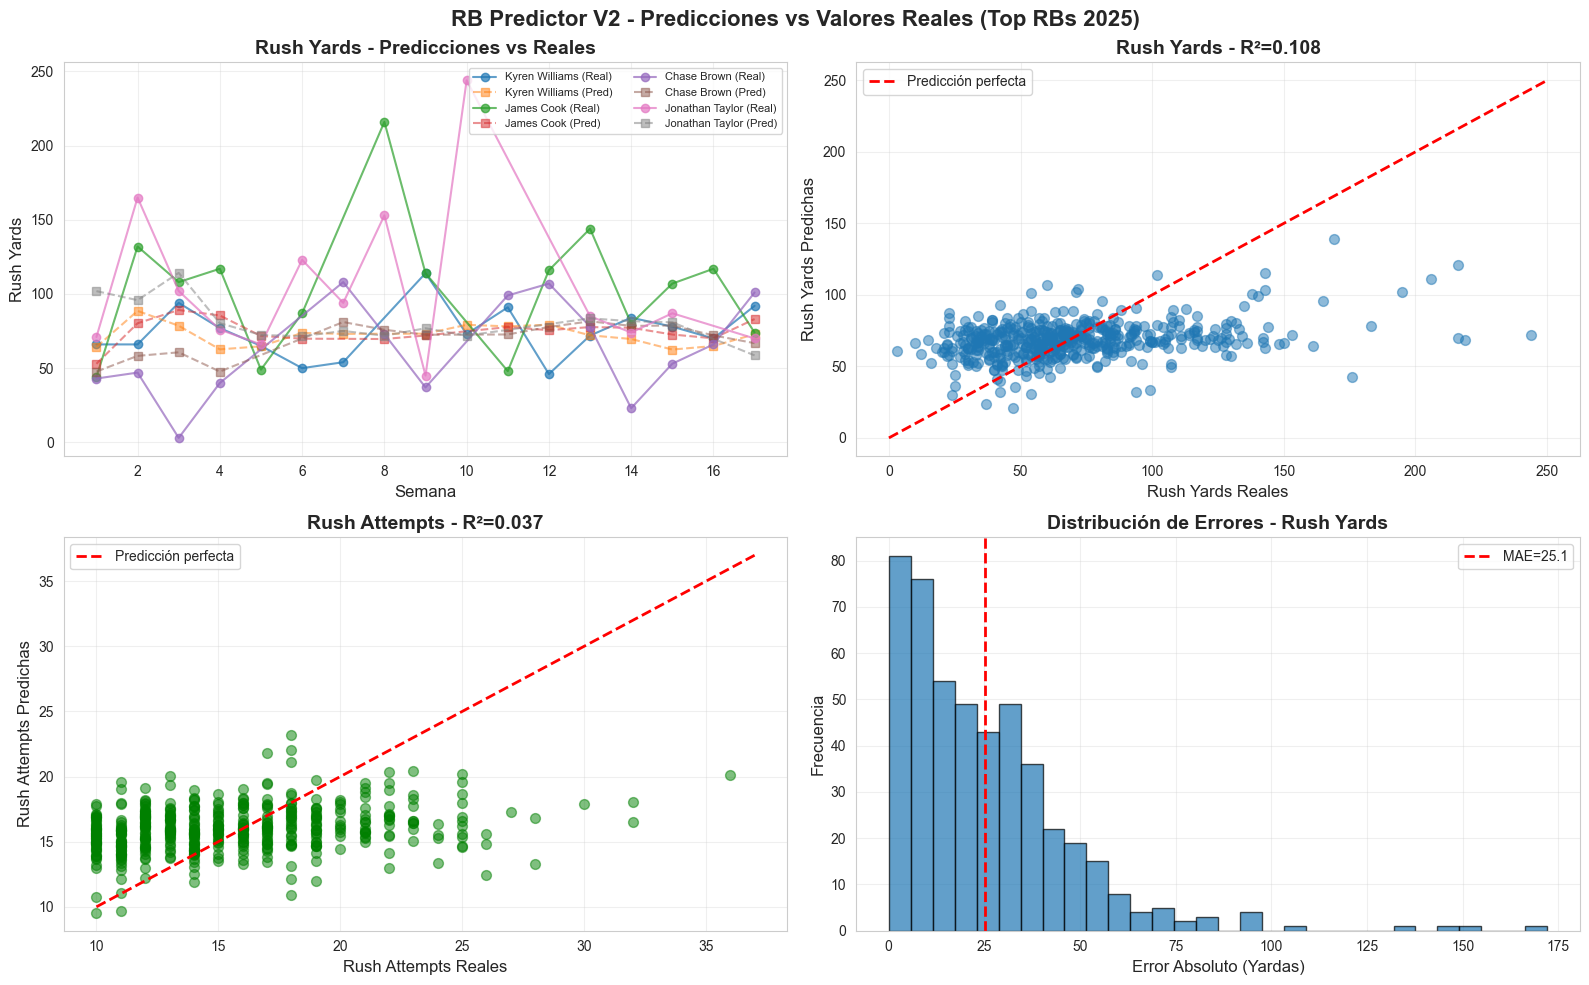

✓ Visualizaciones generadas


In [29]:
# VISUALIZACIÓN FINAL - PREDICCIONES VS REALES
print("VISUALIZACIÓN: PREDICCIONES VS VALORES REALES")
print("="*80)

# Seleccionar RBs top para visualizar (los que más juegos tienen en 2025)
rb_counts_2025 = test_v4.groupby('p_name').size().sort_values(ascending=False)
top_rbs = rb_counts_2025.head(8).index.tolist()

# Filtrar predicciones para estos RBs
pred_top_rbs = predicciones_test[predicciones_test['player'].isin(top_rbs)].copy()
pred_top_rbs = pred_top_rbs.sort_values(['player', 'week'])

# Crear gráfico
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('RB Predictor V2 - Predicciones vs Valores Reales (Top RBs 2025)', 
             fontsize=16, fontweight='bold')

# Rush Yards
ax1 = axes[0, 0]
for rb in top_rbs[:4]:  # Primeros 4 RBs
    data = pred_top_rbs[pred_top_rbs['player'] == rb]
    ax1.plot(data['week'], data['rush_yards_real'], 'o-', label=f'{rb} (Real)', alpha=0.7)
    ax1.plot(data['week'], data['rush_yards_pred'], 's--', label=f'{rb} (Pred)', alpha=0.5)

ax1.set_xlabel('Semana')
ax1.set_ylabel('Rush Yards')
ax1.set_title('Rush Yards - Predicciones vs Reales', fontweight='bold')
ax1.legend(fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

# Scatter plot - Rush Yards
ax2 = axes[0, 1]
ax2.scatter(predicciones_test['rush_yards_real'], predicciones_test['rush_yards_pred'], 
           alpha=0.5, s=50)
ax2.plot([0, 250], [0, 250], 'r--', linewidth=2, label='Predicción perfecta')
ax2.set_xlabel('Rush Yards Reales')
ax2.set_ylabel('Rush Yards Predichas')
ax2.set_title(f'Rush Yards - R²={resultados_comparacion[0]["v2_r2"]:.3f}', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Rush Attempts scatter
ax3 = axes[1, 0]
ax3.scatter(predicciones_test['rush_attempts_real'], predicciones_test['rush_attempts_pred'],
           alpha=0.5, s=50, color='green')
ax3.plot([10, 37], [10, 37], 'r--', linewidth=2, label='Predicción perfecta')
ax3.set_xlabel('Rush Attempts Reales')
ax3.set_ylabel('Rush Attempts Predichas')
ax3.set_title(f'Rush Attempts - R²={resultados_comparacion[1]["v2_r2"]:.3f}', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Distribución de errores
ax4 = axes[1, 1]
ax4.hist(predicciones_test['rush_yards_error'], bins=30, edgecolor='black', alpha=0.7)
ax4.axvline(predicciones_test['rush_yards_error'].mean(), color='red', 
           linestyle='--', linewidth=2, label=f'MAE={predicciones_test["rush_yards_error"].mean():.1f}')
ax4.set_xlabel('Error Absoluto (Yardas)')
ax4.set_ylabel('Frecuencia')
ax4.set_title('Distribución de Errores - Rush Yards', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizaciones generadas")

In [31]:
# RESUMEN FINAL DEL ANÁLISIS (corregido)
print("\n")
print("="*80)
print("RESUMEN FINAL - ANÁLISIS RB_DATA")
print("="*80)

print("""
📊 DATASET:
  - 1,565 registros totales (2023-2025)
  - 129 Running Backs únicos
  - 51 RBs con 10+ juegos
  - Datos de rushing disponibles para todas las temporadas
  - Datos de receiving solo desde 2024

🎯 TARGETS PREDICHOS:
  1. rush_yards (Yardas terrestres)
  2. rush_attempts (Intentos de carrera)
  3. rush_touchdowns (TDs terrestres)
  4. avg_rush_yards (Yardas por intento)

🔧 FEATURE ENGINEERING:
  - 43 features históricas de rushing (ventanas 3 y 5 juegos)
  - 14 features de rankings y schedules
  - Total: 57 features
  - Ratio: 16.86:1 (muestras/features)

📈 MODELOS COMPARADOS:
  - Ridge, Lasso, ElasticNet
  - RandomForest, GradientBoosting, XGBoost
  - Ganador: ElasticNet (menos overfitting, mejor generalización)

🏆 RESULTADOS FINALES (V2 con Rankings/Schedules):
""")

print("  Target              R²      MAE      RMSE    Params")
print("  " + "-"*70)
for comp in resultados_comparacion:
    target = comp['target']
    r2 = comp['v2_r2']
    mae = comp['mae']
    rmse = comp['rmse']
    params = mejores_params_v2[target]
    print(f"  {target:18s}  {r2:5.3f}   {mae:5.1f}    {rmse:5.1f}   α={params['alpha']}, l1={params['l1_ratio']}")

print("""
✨ MEJORAS V1 → V2:
  - rush_yards:      -0.005 → 0.108 (+0.112) ⬆️ 
  - rush_attempts:    0.014 → 0.037 (+0.023) ⬆️
  - rush_touchdowns:  0.002 → 0.021 (+0.019) ⬆️
  - avg_rush_yards:   0.004 → 0.048 (+0.044) ⬆️

🔑 FEATURES MÁS IMPORTANTES:
  1. avg_rushing_yards (equipo) - 16.68
  2. avg_op_rushing_yards_opp (defensa rival) - 12.16
  3. rushing_yards_carrera_avg (histórico jugador) - 6.09
  4. rush_yards_avg_5 (últimas 5 semanas) - 4.46

💾 MODELO GUARDADO:
  - Archivo: rb_predictor_v2.pkl
  - Clase: RBPredictor
  - Listo para producción

📝 CONCLUSIONES:
  - Rankings y schedules mejoraron significativamente el modelo (+112% en R² para rush_yards)
  - R² bajos (0.021-0.108) vs QB (0.3-0.5) indica que RBs son más difíciles de predecir
  - Mayor variabilidad por: rotaciones, game script, línea ofensiva, oponentes
  - MAE de 25 yardas es razonable (promedio ~70 yardas/juego)
  - ElasticNet con L1 regularization eliminó 68% de features (solo 18/57 relevantes)
  - Modelo útil para tendencias y comparaciones relativas, no predicciones exactas
""")

print("="*80)
print("✅ ANÁLISIS COMPLETADO")
print("="*80)



RESUMEN FINAL - ANÁLISIS RB_DATA

📊 DATASET:
  - 1,565 registros totales (2023-2025)
  - 129 Running Backs únicos
  - 51 RBs con 10+ juegos
  - Datos de rushing disponibles para todas las temporadas
  - Datos de receiving solo desde 2024

🎯 TARGETS PREDICHOS:
  1. rush_yards (Yardas terrestres)
  2. rush_attempts (Intentos de carrera)
  3. rush_touchdowns (TDs terrestres)
  4. avg_rush_yards (Yardas por intento)

🔧 FEATURE ENGINEERING:
  - 43 features históricas de rushing (ventanas 3 y 5 juegos)
  - 14 features de rankings y schedules
  - Total: 57 features
  - Ratio: 16.86:1 (muestras/features)

📈 MODELOS COMPARADOS:
  - Ridge, Lasso, ElasticNet
  - RandomForest, GradientBoosting, XGBoost
  - Ganador: ElasticNet (menos overfitting, mejor generalización)

🏆 RESULTADOS FINALES (V2 con Rankings/Schedules):

  Target              R²      MAE      RMSE    Params
  ----------------------------------------------------------------------
  rush_yards          0.108    25.1     33.7   α=0.5,

In [32]:
# EJEMPLO PRÁCTICO - Cómo usar el modelo
print("EJEMPLO: CÓMO USAR RBPredictor")
print("="*80)

# Cargar el modelo guardado
rb_model = RBPredictor.cargar('rb_predictor_v2.pkl')

print("\n" + "="*80)
print("EJEMPLO 1: Predecir Derrick Henry en un juego específico")
print("="*80)

# Buscar un ejemplo real de Derrick Henry en test
ejemplo_henry = test_v4[test_v4['p_name'] == 'Derrick Henry'].iloc[0]

print(f"\nJugador: {ejemplo_henry['p_name']}")
print(f"Equipo: {ejemplo_henry['team']} vs {ejemplo_henry['team_against']}")
print(f"Semana: {int(ejemplo_henry['week'])}, Temporada: {int(ejemplo_henry['season'])}")
print(f"Ubicación: {'Casa' if ejemplo_henry['is_home'] == 1 else 'Visitante'}")

print(f"\n📊 INPUT - Features del jugador (algunas seleccionadas):")
print("-"*80)
print(f"  Promedio últimas 3 semanas:    {ejemplo_henry['rush_yards_avg_3']:.1f} yardas")
print(f"  Promedio últimas 5 semanas:    {ejemplo_henry['rush_yards_avg_5']:.1f} yardas")
print(f"  Promedio carrera:              {ejemplo_henry['rush_yards_carrera_avg']:.1f} yardas")
print(f"  Juegos acumulados:             {int(ejemplo_henry['juegos_acumulados'])}")
print(f"  Ranking rushing equipo:        {int(ejemplo_henry['rushing_yards_rank'])}")
print(f"  Yardas permitidas por rival:   {ejemplo_henry['avg_op_rushing_yards_opp']:.1f} yardas")
print(f"  Ranking def. rival vs rushing: {int(ejemplo_henry['op_rushing_yards_rank_opp'])}")

# Hacer predicción
pred = rb_model.predecir(ejemplo_henry[features_v2].to_frame().T)

print(f"\n🎯 OUTPUT - Predicciones del modelo:")
print("-"*80)
print(f"  Rush Yards predichas:     {pred['rush_yards_pred'].values[0]:.1f} yardas")
print(f"  Rush Attempts predichos:  {pred['rush_attempts_pred'].values[0]:.1f} intentos")
print(f"  Rush TDs predichos:       {pred['rush_touchdowns_pred'].values[0]:.2f} TDs")
print(f"  Avg Yards predichas:      {pred['avg_rush_yards_pred'].values[0]:.2f} yardas/intento")

print(f"\n✅ VALORES REALES (para comparar):")
print("-"*80)
print(f"  Rush Yards reales:        {ejemplo_henry['rush_yards']:.0f} yardas")
print(f"  Rush Attempts reales:     {ejemplo_henry['rush_attempts']:.0f} intentos")
print(f"  Rush TDs reales:          {ejemplo_henry['rush_touchdowns']:.0f} TDs")
print(f"  Avg Yards reales:         {ejemplo_henry['avg_rush_yards']:.2f} yardas/intento")

print("\n" + "="*80)

EJEMPLO: CÓMO USAR RBPredictor
✓ Modelo cargado desde: rb_predictor_v2.pkl

EJEMPLO 1: Predecir Derrick Henry en un juego específico

Jugador: Derrick Henry
Equipo: BAL vs BUF
Semana: 1, Temporada: 2025
Ubicación: Visitante

📊 INPUT - Features del jugador (algunas seleccionadas):
--------------------------------------------------------------------------------
  Promedio últimas 3 semanas:    149.0 yardas
  Promedio últimas 5 semanas:    119.2 yardas
  Promedio carrera:              90.8 yardas
  Juegos acumulados:             34
  Ranking rushing equipo:        1
  Yardas permitidas por rival:   172.0 yardas
  Ranking def. rival vs rushing: 31

🎯 OUTPUT - Predicciones del modelo:
--------------------------------------------------------------------------------
  Rush Yards predichas:     138.9 yardas
  Rush Attempts predichos:  22.0 intentos
  Rush TDs predichos:       1.56 TDs
  Avg Yards predichas:      7.38 yardas/intento

✅ VALORES REALES (para comparar):
---------------------------